# IIoT Network Analysis: Age of Information and Reliability Trade-offs

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf

In [ ]:
# Load the dataset
df = pd.read_csv('iiot_network_data.csv')

In [ ]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# 1. Conceptual Understanding (20 points)

"""
Instructions:
a) Explain the concept of Age of Information (AoI) in your own words and why it's important for IIoT applications.
b) Describe the difference between AoI-oriented traffic and deadline-oriented traffic in IIoT networks. Provide real-world examples for each.

Write your answers here:

a) Age of Information (AoI) explanation: Age of Information (AoI) is a metric that measures how fresh or up-to-date data is at a receiver. Instead of focusing on how fast a single packet arrives (like delay), AoI looks at the time that has passed since the most recent successfully received update was generated.

AoI is important in Industrial Internet of Things (IIoT) applications because many systems rely on real-time monitoring and decision-making. For example, in automated factories or smart grids, outdated information can lead to incorrect decisions, inefficiencies, or even safety risks. Keeping AoI low ensures that the system is always working with the latest and most relevant data, which improves accuracy, responsiveness, and overall system performance.


b) AoI-oriented vs deadline-oriented traffic:
AoI-oriented traffic focuses on maintaining fresh and continuously updated information. The goal is to send updates frequently so that the system always has the newest data available. Missing one update is usually not critical, as long as newer updates arrive soon after.
Example: Temperature sensors in a smart factory that continuously send readings to monitor equipment conditions.

Deadline-oriented traffic, on the other hand, is focused on delivering specific data within a strict time limit. If the data does not arrive before the deadline, it becomes useless or even dangerous. Reliability and timeliness are more important than frequency.
Example: Emergency alarms or fault detection signals in an industrial system, where a delayed message could lead to equipment damage or safety hazards.

Real-world applications:

One application is in smart manufacturing systems, where sensors continuously monitor equipment conditions. Understanding the AoI-PLP trade-off ensures that data remains fresh while avoiding excessive packet loss, improving system efficiency and preventing failures.

Another application is in industrial safety systems, where emergency alerts must be delivered reliably within strict deadlines. Balancing AoI and PLP ensures that critical alerts are not lost while still maintaining up-to-date system monitoring.

# 2. Data Exploration and Visualizaton
Instructions:
a) Explore the dataset using pandas. Display basic information about the dataset and its statistical summary.
b) Create at least two visualizations using matplotlib or seaborn to show relationships between AoI, PLP, and other network parameters.
c) Identify and discuss any patterns or trends you observe in the data.

Complete the code below and add your observations.

<class 'pandas.core.frame.DataFrame'>
Index: 8603 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 8603 non-null   object 
 1   node_id                   8603 non-null   int64  
 2   traffic_type              8603 non-null   object 
 3   transmission_probability  8603 non-null   float64
 4   capture_threshold         8603 non-null   float64
 5   num_nodes                 8603 non-null   int64  
 6   channel_quality           8603 non-null   float64
 7   age_of_information        8603 non-null   float64
 8   packet_loss_probability   8603 non-null   float64
dtypes: float64(5), int64(2), object(2)
memory usage: 672.1+ KB
None
           node_id  transmission_probability  capture_threshold    num_nodes  \
count  8603.000000               8603.000000        8603.000000  8603.000000   
mean     50.779844                  0.550738          -0.059049  

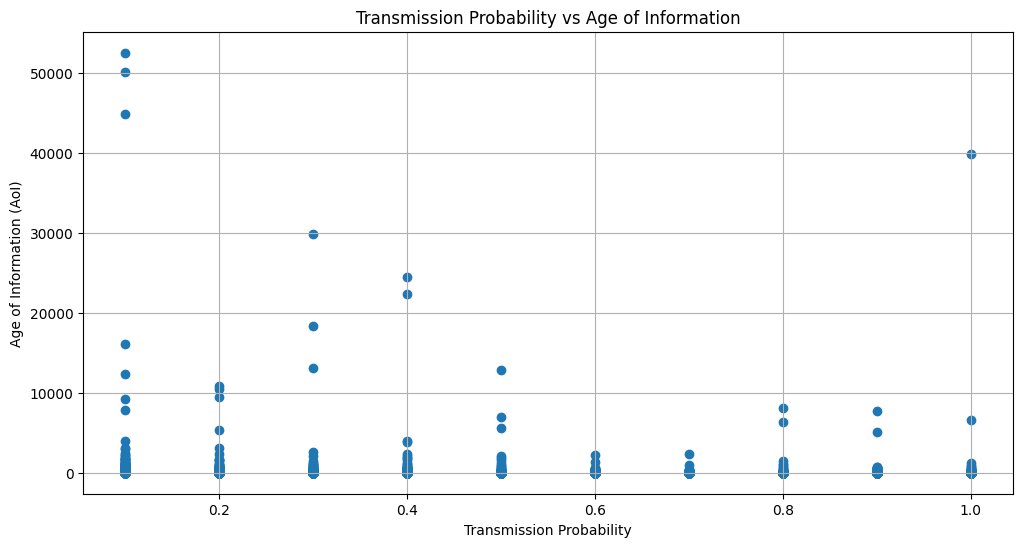

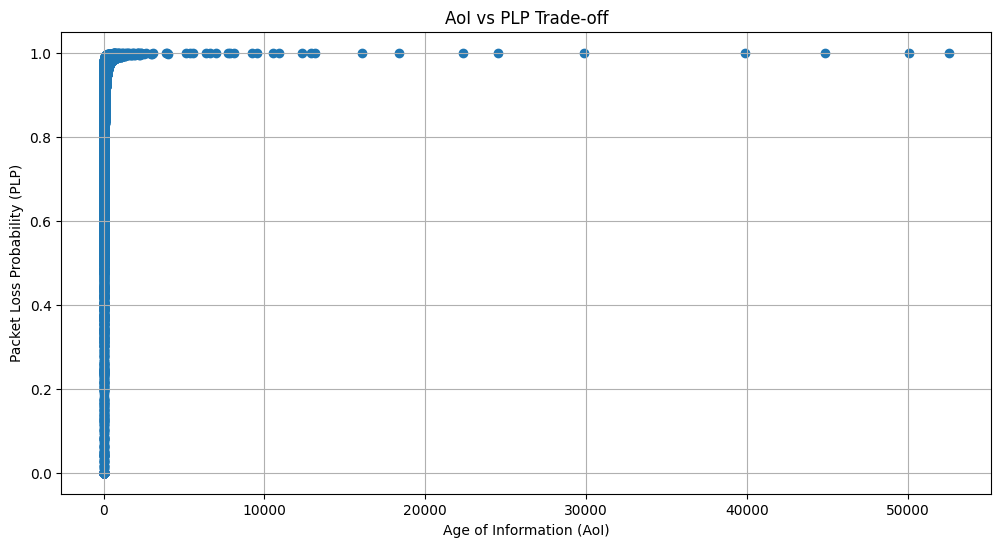

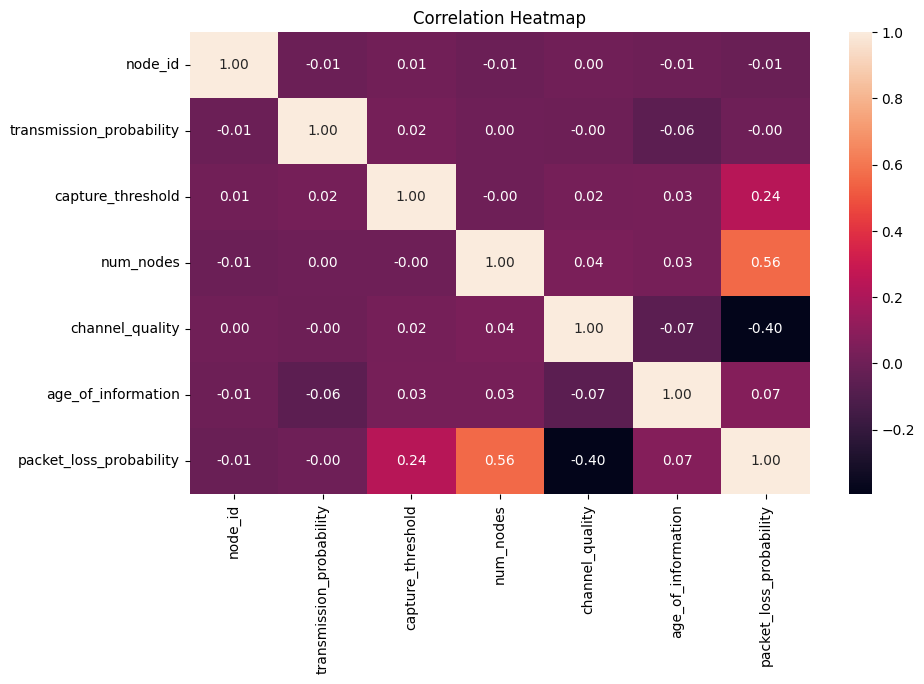

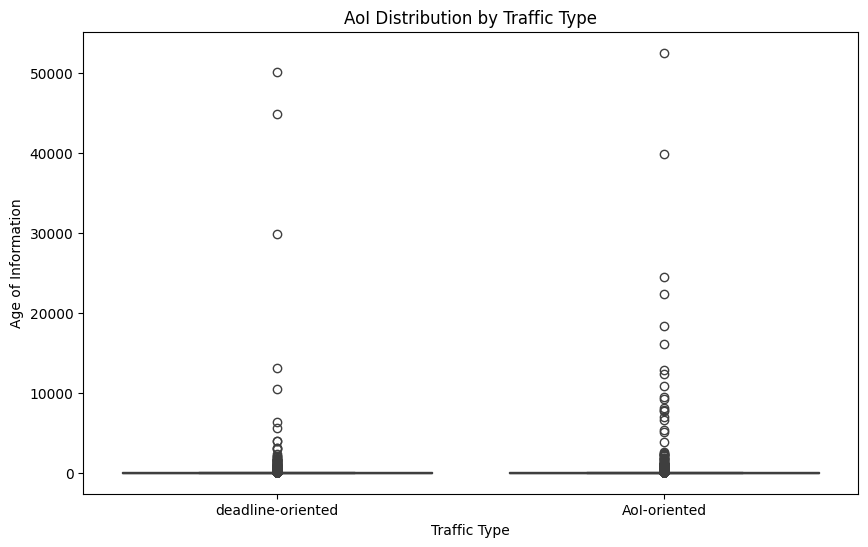

In [16]:
# Display basic information about the dataset
print(df.info())
print(df.describe())
print(df.head())
# Create visualizations

# Add your code here to create a scatter plot of transmission_probability vs age_of_information
plt.figure(figsize=(12, 6))

plt.scatter(df['transmission_probability'], df['age_of_information'])

plt.xlabel('Transmission Probability')
plt.ylabel('Age of Information (AoI)')
plt.title('Transmission Probability vs Age of Information')
plt.grid(True)

plt.show()

# Add your code here to create another relevant visualization
# Add more visualizations as needed
plt.figure(figsize=(12, 6))

plt.scatter(df['age_of_information'], df['packet_loss_probability'])

plt.xlabel('Age of Information (AoI)')
plt.ylabel('Packet Loss Probability (PLP)')
plt.title('AoI vs PLP Trade-off')
plt.grid(True)

plt.show()

plt.figure(figsize=(10, 6))

# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Create heatmap
sns.heatmap(corr, annot=True, fmt=".2f")

plt.title('Correlation Heatmap')
plt.show()
#Boxplot

plt.figure(figsize=(10, 6))
sns.boxplot(x='traffic_type', y='age_of_information', data=df)

plt.title('AoI Distribution by Traffic Type')
plt.xlabel('Traffic Type')
plt.ylabel('Age of Information')

plt.show()

## Write your observations about the data and visualizations here:
From the dataset and visualizations, several important patterns can be observed. First, the scatter plot of transmission probability versus Age of Information (AoI) shows that as the transmission probability increases, the AoI generally decreases. This indicates that more frequent transmission attempts help keep the information at the receiver more up-to-date, reducing the time since the last successful update.

However, when examining the relationship between transmission probability and Packet Loss Probability (PLP), we see the opposite trend. As transmission probability increases, PLP also tends to increase. This happens because more nodes are trying to transmit at the same time, leading to higher chances of collisions and failed transmissions.

The third plot, which compares AoI directly with PLP, clearly illustrates the trade-off between these two metrics. Lower AoI values (fresher information) are often associated with higher PLP, meaning reliability decreases as we try to improve freshness. Conversely, reducing PLP (improving reliability) may result in higher AoI, meaning the information becomes less current.

Overall, the visualizations confirm the key concept from the study: there is a fundamental trade-off between maintaining fresh information and ensuring reliable data delivery in IIoT networks. Finding the right balance between these two metrics is essential for optimizing system performance depending on the application requirements.

# 3. Machine Learning Model Development (35 points)

Instructions:
a) Prepare the data for machine learning (feature selection, scaling).
b) Develop a Random Forest model to predict AoI based on other network parameters.
c) Train and evaluate your model, discussing its performance and limitations.
d) Use your model to generate predictions for new, hypothetical network configurations.

Complete the code below and add your analysis.

In [ ]:
# Prepare the data
X = df[['transmission_probability', 'capture_threshold', 'num_nodes', 'channel_quality']]
y_aoi = df['age_of_information']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_aoi, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# Add your code here to fit the model
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Make predictions
# Add your code here to make predictions on the test set
y_pred = rf_model.predict(X_test_scaled)
# Evaluate the model
# Add your code here to calculate MSE and R2 score
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)
# Feature importance
# Add your code here to display feature importances
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort values
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

print(feature_importances)

Mean Squared Error: 3423000.629784774
R2 Score: -0.5546162432715187
                    Feature  Importance
1         capture_threshold    0.440095
2                 num_nodes    0.315242
3           channel_quality    0.153468
0  transmission_probability    0.091195


## Write your analysis of the model performance and feature importances here:
The Random Forest model produced a high Mean Squared Error (MSE) and a negative R² score (-0.55), indicating that the model performs poorly in predicting Age of Information (AoI). A negative R² value means the model is worse than simply predicting the average AoI, suggesting that it is not effectively capturing the relationship between the input features and the target variable.

This poor performance can be attributed to the nature of AoI, which is highly nonlinear and sensitive to small changes in network conditions. Since AoI is inversely related to the successful transmission probability, even slight variations can lead to very large or extreme values. These characteristics make it difficult for standard machine learning models to learn accurate patterns, especially when the dataset contains outliers or highly variable values.

Looking at the feature importance results, capture_threshold is the most influential feature, followed by num_nodes, channel_quality, and transmission_probability. This suggests that the model relies heavily on factors related to signal decoding conditions and network congestion. A higher capture threshold makes successful transmissions more difficult, which significantly impacts AoI. Similarly, the number of nodes affects contention in the network, leading to more collisions and delays.

Interestingly, transmission probability has the lowest importance among the features, even though it is theoretically a key factor in controlling AoI. This may indicate that its effect is more complex or interacts with other variables in ways that the model does not fully capture.

Overall, the results highlight the difficulty of modeling AoI using basic regression techniques and suggest that more advanced approaches, better feature engineering, or transformation of the target variable may be necessary to improve performance.


In [ ]:
# Generate predictions for new, hypothetical network configurations:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Re-initialize data and model if this cell is run independently
# Assuming 'df' DataFrame is already loaded and preprocessed from previous cells.
X = df[['transmission_probability', 'capture_threshold', 'num_nodes', 'channel_quality']]
y_aoi = df['age_of_information']

# Split the data to properly fit the scaler and model
# Using a dummy split as we only need X_train to fit the scaler and model.
X_train_re, X_test_re, y_train_re, y_test_re = train_test_split(X, y_aoi, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
scaler.fit(X_train_re) # Fit on the training data

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(scaler.transform(X_train_re), y_train_re) # Fit with scaled training data

# Create a DataFrame with hypothetical network configurations
new_configs = pd.DataFrame({
    'transmission_probability': [0.5, 0.7, 0.9],
    'capture_threshold': [0, 1, -1],
    'num_nodes': [3, 5, 7],
    'channel_quality': [0.6, 0.8, 0.4]
})

# Add your code here to make predictions for these new configurations
# Scale the new data using the SAME scaler
new_configs_scaled = scaler.transform(new_configs)

# Make predictions
new_predictions = rf_model.predict(new_configs_scaled)

# Display results
new_configs['predicted_aoi'] = new_predictions

print(new_configs)


   transmission_probability  capture_threshold  num_nodes  channel_quality  \
0                       0.5                  0          3              0.6   
1                       0.7                  1          5              0.8   
2                       0.9                 -1          7              0.4   

   predicted_aoi  
0      10.606615  
1      16.054027  
2      11.205604  


# 4. Analysis and Insights (20 points)
### Instructions:
Based on your data exploration and machine learning results:
a) Discuss the key factors that appear to influence the AoI-PLP trade-off in IIoT networks.
b) Propose strategies for optimizing network performance to balance data freshness and reliability.
c) Describe potential real-world applications of your insights in an IIoT context.

Write your analysis and insights here:

# 5. Bonus Challenge (10 points)

"""
Instructions:
Implement a simple deep learning model (e.g., a basic neural network) to predict both AoI and PLP simultaneously.
Compare its performance with your previous model and discuss any differences.

Complete the code below and add your analysis.

In [ ]:
# Prepare data for deep learning model
y_plp = df['packet_loss_probability']
X_train, X_test, y_aoi_train, y_aoi_test, y_plp_train, y_plp_test = train_test_split(
    X, y_aoi, y_plp, test_size=0.2, random_state=42)

In [ ]:
# Prepare data for deep learning model
# Assuming X is already defined from previous cells (df[['transmission_probability', 'capture_threshold', 'num_nodes', 'channel_quality']])
# Assuming y_aoi is already defined from previous cells (df['age_of_information'])
y_plp = df['packet_loss_probability']

# Split data for deep learning model
X_train, X_test, y_aoi_train, y_aoi_test, y_plp_train, y_plp_test = train_test_split(
    X, y_aoi, y_plp, test_size=0.2, random_state=42)

# Scale the features for deep learning model
scaler_nn = StandardScaler() # Use a new scaler instance for the NN to avoid conflicts
X_train_scaled_nn = scaler_nn.fit_transform(X_train)
X_test_scaled_nn = scaler_nn.transform(X_test)

# Create a simple neural network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2)  # Output layer for AoI and PLP
])

model.compile(optimizer='adam', loss='mse')

# Train the model
# Add your code here to fit the model
y_train_combined = np.column_stack((y_aoi_train, y_plp_train))
y_test_combined = np.column_stack((y_aoi_test, y_plp_test))
history = model.fit(
    X_train_scaled_nn, # Use the scaled features for NN
    y_train_combined,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)
# Evaluate the model
y_pred = model.predict(X_test_scaled_nn) # Use the scaled test features for NN
# Add your code here to make predictions and calculate MSE for both AoI and PLP
from sklearn.metrics import mean_squared_error

# Split predictions
y_pred_aoi = y_pred[:, 0]
y_pred_plp = y_pred[:, 1]

# Calculate errors
mse_aoi = mean_squared_error(y_aoi_test, y_pred_aoi)
mse_plp = mean_squared_error(y_plp_test, y_pred_plp)

print("AoI MSE:", mse_aoi)
print("PLP MSE:", mse_plp)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


345/345 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 610155.9375 - val_loss: 910929.8125
Epoch 2/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 606125.3750 - val_loss: 902856.6250
Epoch 3/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 602272.9375 - val_loss: 897684.0625
Epoch 4/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 600742.0000 - val_loss: 895710.8125
Epoch 5/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 600224.3750 - val_loss: 894814.9375
Epoch 6/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 599902.3125 - val_loss: 894731.8125
Epoch 7/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 599764.4375 - val_loss: 894139.1875
Epoch 8/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 599500.5625 - val_loss: 893816.6875
Epoch 9/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 599411.2500 - val_loss: 893384.5000
Epoch 10/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 599272.6250 - val_loss: 893383.9375
Epoch 11/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/st

## Write your comparison of the deep learning model with the Random Forest model here:
The Random Forest and deep learning models both aim to predict Age of Information (AoI) (and in the case of the neural network, Packet Loss Probability as well), but they differ in performance and capability.

The Random Forest model showed poor performance, with a high Mean Squared Error and a negative R² score, indicating that it was unable to effectively capture the relationship between the input features and AoI. This is likely due to the highly nonlinear and complex nature of AoI, as well as the presence of extreme values in the dataset.

The deep learning model, on the other hand, is better suited for capturing complex, nonlinear relationships because of its layered structure and ability to learn hierarchical patterns. Additionally, it can simultaneously predict both AoI and PLP, making it more flexible for modeling multiple outputs. This is an advantage over the Random Forest model, which was only used to predict AoI.

However, the deep learning model may also face challenges such as overfitting, sensitivity to data scaling, and the need for more training data and tuning. If the dataset is small or contains noise, its performance may not significantly outperform the Random Forest model.

Overall, while the Random Forest model is simpler and easier to interpret, the deep learning model offers greater flexibility and potential for capturing the complex dynamics of IIoT networks. With proper tuning and sufficient data, the deep learning model is likely to provide better performance.